### Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import timm
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
from torchvision import transforms

from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

### Train Val Split

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv")

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=876567
)

train_idx, val_idx = next(sgkf.split(df, df['dx'], df['lesion_id']))
df['split'] = 'train'
df.loc[val_idx, 'split'] = 'val'

output_filename = "HAM10000_metadata_split_80_20.csv"
df.to_csv(output_filename, index=False)

split = pd.read_csv("/kaggle/working/HAM10000_metadata_split_80_20.csv")

train_df = split[split['split'] == 'train']
val_df = split[split['split'] == 'val']

print(train_df.shape)
print(val_df.shape)

(8033, 8)
(1982, 8)


### Caching

In [3]:
IMG_SIZE = 380
img_dirs = [
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1',
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2'
]

label_map = {label : idx for idx, label in enumerate(sorted(split['dx'].unique()))}

path_map = {}
for d in img_dirs:
    for fname in os.listdir(d):
        if fname.endswith(".jpg"):
            image_id = fname[:-4]
            path_map[image_id] = os.path.join(d, fname)

resize_only = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

def build_cache(df, path_map, save_path):
    images = torch.zeros((len(df), 3, 380, 380), dtype=torch.float32)
    for i, row in df.reset_index(drop=True).iterrows():
        img = Image.open(path_map[row['image_id']]).convert('RGB')
        images[i] = resize_only(img)
        if i % 1000 == 0:
            print(f"{i}/{len(df)}")
    torch.save(images, save_path)
    print(f"Saved cache to {save_path}")

# build once, reuse across all 20 epochs
build_cache(train_df, path_map, '/kaggle/working/train_cache.pt')
build_cache(val_df, path_map, '/kaggle/working/val_cache.pt')

0/8033
1000/8033
2000/8033
3000/8033
4000/8033
5000/8033
6000/8033
7000/8033
8000/8033
Saved cache to /kaggle/working/train_cache.pt
0/1982
1000/1982
Saved cache to /kaggle/working/val_cache.pt


In [4]:
class_names = sorted(label_map, key=label_map.get)

print(class_names)
print(label_map)

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


### Dataset/DataLoader

In [5]:
class CachedHAMDataset(Dataset):
    def __init__(self, cache_path, df, label_map, augment=None):
        self.images = torch.load(cache_path)
        self.labels = [label_map[l] for l in df['dx']]

        # augmentation
        self.train_aug = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(20),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1)
        ])

        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]

        if self.augment:
            img = self.train_aug(img)

        return img, self.labels[idx]


# ---

train_cache_path = "/kaggle/working/train_cache.pt"
val_cache_path = "/kaggle/working/val_cache.pt"

train_ds = CachedHAMDataset(train_cache_path, train_df, label_map, augment=True)
val_ds = CachedHAMDataset(val_cache_path, val_df, label_map, augment=False)

class_counts = train_df['dx'].value_counts().reindex(class_names)
class_weights = 1.0 / class_counts
sample_weights = train_df['dx'].map(class_weights).values

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    sampler=sampler,
    drop_last=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

### Training

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

model = timm.create_model(
    "efficientnet_b4",
    pretrained=True,
    num_classes=7,
    drop_rate=0.3, # dropout before final classifier
    drop_path_rate=0.2 # stochastic depth — drops entire residual blocks during training
)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3) # 10x increase l2-regularization
scaler = GradScaler()

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device)

        images = (images - MEAN) / STD

        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device)
            images = (images - MEAN) / STD

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return running_loss / total, correct / total, macro_f1

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

In [ ]:
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'val_f1': []
}

best_f1 = 0.0
NUM_EPOCHS = 30
CHECKPOINT_PATH = 'best_model_oversample_aug_dropout.pth'

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_f1,
        }, CHECKPOINT_PATH)
        print(f"  → New best model saved (F1: {val_f1:.4f})")

print(f"\nTraining complete. Best Val F1: {best_f1:.4f}")

Epoch 1/30 | Train Loss: 1.5876 Acc: 0.4478 | Val Loss: 1.2280 Acc: 0.6322 F1: 0.4485 \
  → New best model saved (F1: 0.4485) \
Epoch 2/30 | Train Loss: 1.1132 Acc: 0.6911 | Val Loss: 1.0726 Acc: 0.7114 F1: 0.5863 \
  → New best model saved (F1: 0.5863) \
Epoch 3/30 | Train Loss: 0.9572 Acc: 0.7755 | Val Loss: 1.0148 Acc: 0.7538 F1: 0.6306 \
  → New best model saved (F1: 0.6306) \
Epoch 4/30 | Train Loss: 0.8611 Acc: 0.8208 | Val Loss: 0.9966 Acc: 0.7296 F1: 0.6341 \
  → New best model saved (F1: 0.6341) \
Epoch 5/30 | Train Loss: 0.8088 Acc: 0.8461 | Val Loss: 0.9795 Acc: 0.7558 F1: 0.6516 \
  → New best model saved (F1: 0.6516) \
Epoch 6/30 | Train Loss: 0.7609 Acc: 0.8720 | Val Loss: 0.9313 Acc: 0.7760 F1: 0.6747 \
  → New best model saved (F1: 0.6747) \
Epoch 7/30 | Train Loss: 0.7298 Acc: 0.8868 | Val Loss: 0.9255 Acc: 0.7745 F1: 0.6901 \
  → New best model saved (F1: 0.6901) \
Epoch 8/30 | Train Loss: 0.7043 Acc: 0.8969 | Val Loss: 0.8814 Acc: 0.8068 F1: 0.7072 \
  → New best model saved (F1: 0.7072) \
Epoch 9/30 | Train Loss: 0.6642 Acc: 0.9180 | Val Loss: 0.8544 Acc: 0.8184 F1: 0.7110 \
  → New best model saved (F1: 0.7110) \
Epoch 10/30 | Train Loss: 0.6520 Acc: 0.9265 | Val Loss: 0.8506 Acc: 0.8234 F1: 0.7125 \
  → New best model saved (F1: 0.7125) \
Epoch 11/30 | Train Loss: 0.6313 Acc: 0.9349 | Val Loss: 0.8409 Acc: 0.8234 F1: 0.7089 \
Epoch 12/30 | Train Loss: 0.6192 Acc: 0.9381 | Val Loss: 0.8327 Acc: 0.8209 F1: 0.7090 \
Epoch 13/30 | Train Loss: 0.6025 Acc: 0.9458 | Val Loss: 0.8071 Acc: 0.8365 F1: 0.7104 \
Epoch 14/30 | Train Loss: 0.5885 Acc: 0.9504 | Val Loss: 0.7960 Acc: 0.8461 F1: 0.7248 \
  → New best model saved (F1: 0.7248) \
Epoch 15/30 | Train Loss: 0.5789 Acc: 0.9553 | Val Loss: 0.7946 Acc: 0.8542 F1: 0.7364 \
  → New best model saved (F1: 0.7364) \
Epoch 16/30 | Train Loss: 0.5673 Acc: 0.9639 | Val Loss: 0.8318 Acc: 0.8239 F1: 0.7235 \
Epoch 17/30 | Train Loss: 0.5613 Acc: 0.9654 | Val Loss: 0.8084 Acc: 0.8355 F1: 0.7297 \
Epoch 18/30 | Train Loss: 0.5522 Acc: 0.9671 | Val Loss: 0.7709 Acc: 0.8592 F1: 0.7450 \
  → New best model saved (F1: 0.7450) \
Epoch 19/30 | Train Loss: 0.5432 Acc: 0.9699 | Val Loss: 0.7735 Acc: 0.8577 F1: 0.7428 \
Epoch 20/30 | Train Loss: 0.5351 Acc: 0.9749 | Val Loss: 0.7883 Acc: 0.8491 F1: 0.7502 \
  → New best model saved (F1: 0.7502) \
Epoch 21/30 | Train Loss: 0.5325 Acc: 0.9762 | Val Loss: 0.7759 Acc: 0.8537 F1: 0.7428 \
Epoch 22/30 | Train Loss: 0.5266 Acc: 0.9776 | Val Loss: 0.7983 Acc: 0.8375 F1: 0.7386 \
Epoch 23/30 | Train Loss: 0.5221 Acc: 0.9796 | Val Loss: 0.7756 Acc: 0.8517 F1: 0.7420 \
Epoch 24/30 | Train Loss: 0.5193 Acc: 0.9795 | Val Loss: 0.7623 Acc: 0.8633 F1: 0.7437 \
Epoch 25/30 | Train Loss: 0.5148 Acc: 0.9811 | Val Loss: 0.7771 Acc: 0.8537 F1: 0.7462 \
Epoch 26/30 | Train Loss: 0.5044 Acc: 0.9853 | Val Loss: 0.7728 Acc: 0.8602 F1: 0.7452 \
Epoch 27/30 | Train Loss: 0.5028 Acc: 0.9854 | Val Loss: 0.7632 Acc: 0.8613 F1: 0.7445 \
Epoch 28/30 | Train Loss: 0.5009 Acc: 0.9873 | Val Loss: 0.7689 Acc: 0.8557 F1: 0.7359 \
Epoch 29/30 | Train Loss: 0.5000 Acc: 0.9856 | Val Loss: 0.7618 Acc: 0.8693 F1: 0.7586 \
  → New best model saved (F1: 0.7586) \
Epoch 30/30 | Train Loss: 0.4950 Acc: 0.9871 | Val Loss: 0.7630 Acc: 0.8668 F1: 0.7520

Training complete. Best Val F1: 0.7586

### Plots

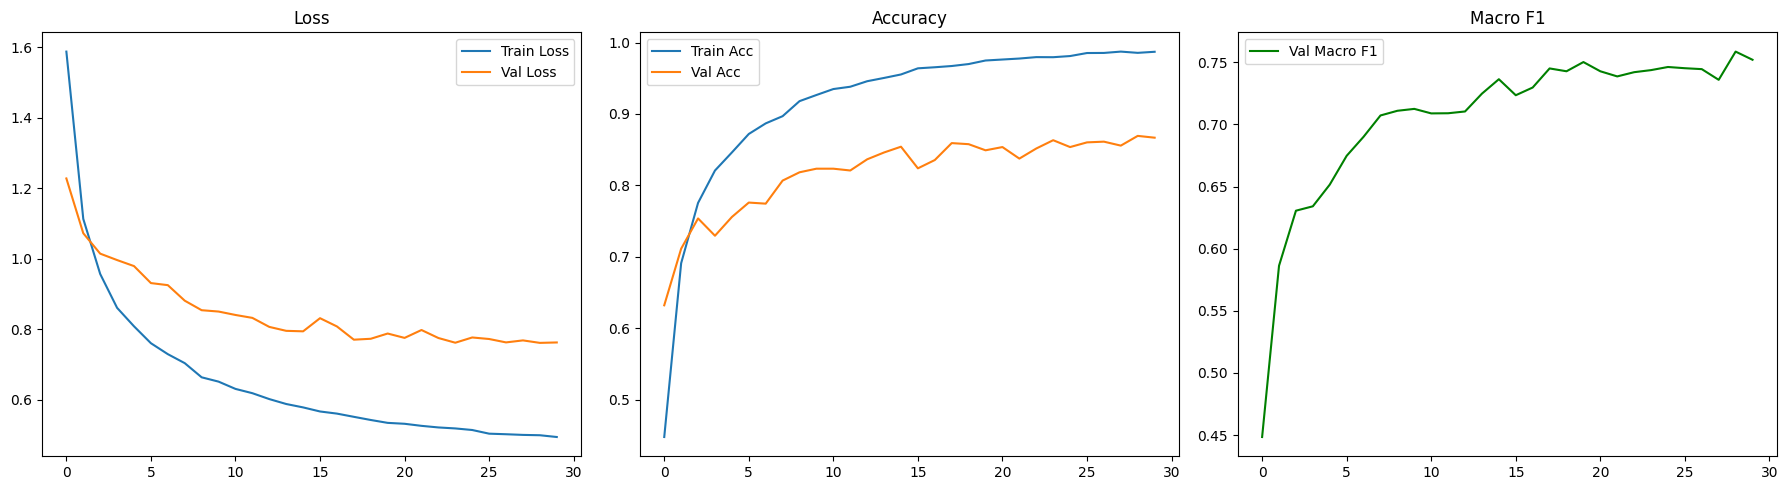

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_title('Accuracy'); axes[1].legend()

axes[2].plot(history['val_f1'], label='Val Macro F1', color='green')
axes[2].set_title('Macro F1'); axes[2].legend()

plt.tight_layout()
plt.show()

Loaded best model from epoch 29, F1: 0.7586


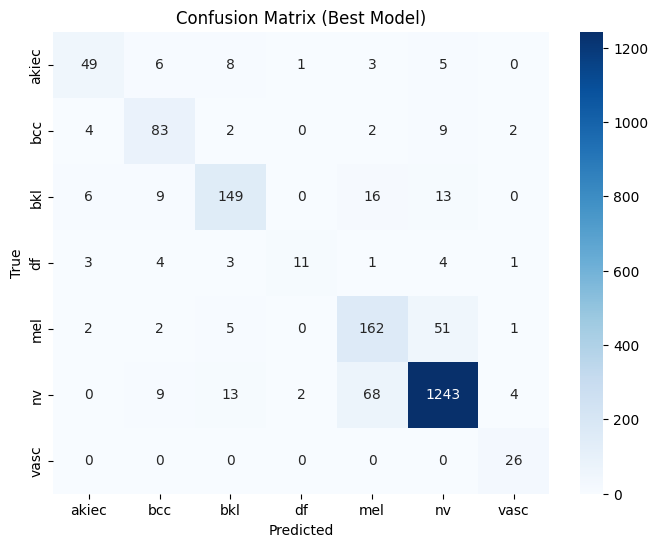

              precision    recall  f1-score   support

       akiec      0.766     0.681     0.721        72
         bcc      0.735     0.814     0.772       102
         bkl      0.828     0.772     0.799       193
          df      0.786     0.407     0.537        27
         mel      0.643     0.726     0.682       223
          nv      0.938     0.928     0.933      1339
        vasc      0.765     1.000     0.867        26

    accuracy                          0.869      1982
   macro avg      0.780     0.761     0.759      1982
weighted avg      0.873     0.869     0.870      1982



In [9]:
checkpoint = torch.load(CHECKPOINT_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}, F1: {checkpoint['val_f1']:.4f}")

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        images = (images - MEAN) / STD
        with torch.cuda.amp.autocast():
            outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = sorted(label_map, key=label_map.get)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix (Best Model)')
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))